# CATSA Dataset Plot

This notebook scans the CATSA dataset at:

`/home/binghin2/Myproject/Dataset/CATSA`

and visualizes:
- file count by task and sensor
- sample length distribution by sensor
- example time-series from one subject/task

Total files: 1,250
Subjects: 50
Tasks: Baseline, Logic, Nback, Stroop, Sudoku
Sensors: ACC, BVP, EDA, HR, TEMP


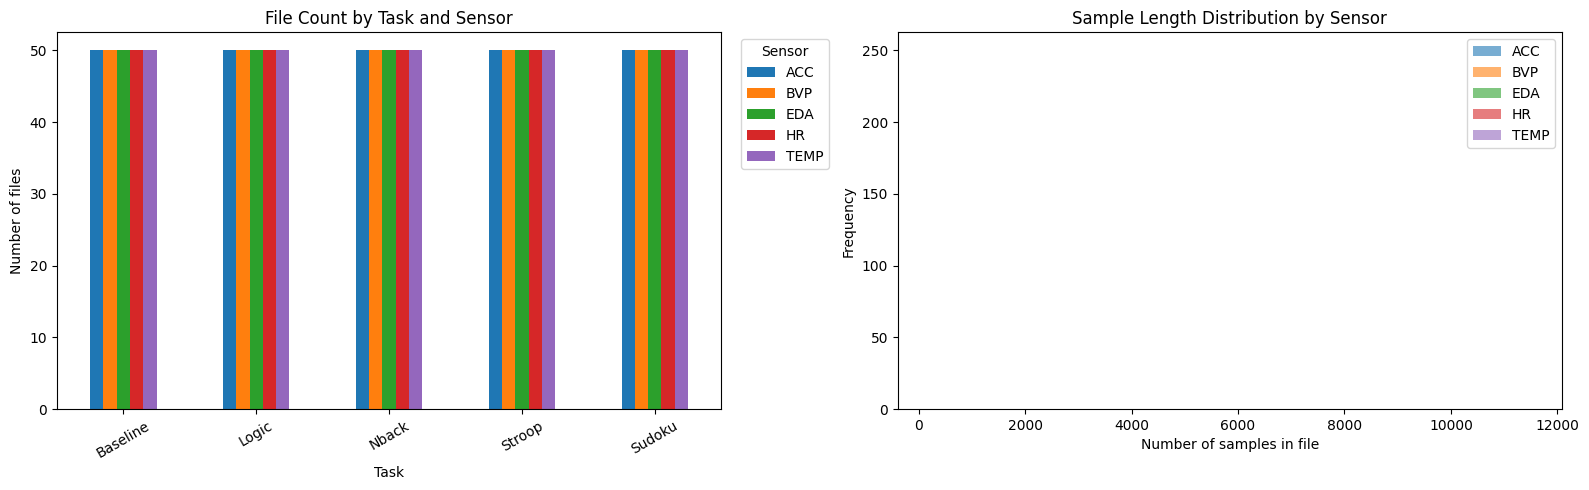

,subject,task,sensor,n_samples,path
0,Sub1,Baseline,ACC,5760,/home/binghin2/Myproject/Dataset/CATSA/Sub1/Ba...
1,Sub1,Baseline,BVP,11520,/home/binghin2/Myproject/Dataset/CATSA/Sub1/Ba...
2,Sub1,Baseline,EDA,720,/home/binghin2/Myproject/Dataset/CATSA/Sub1/Ba...
3,Sub1,Baseline,HR,180,/home/binghin2/Myproject/Dataset/CATSA/Sub1/Ba...
4,Sub1,Baseline,TEMP,720,/home/binghin2/Myproject/Dataset/CATSA/Sub1/Ba...


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset root
DATASET_ROOT = Path('/home/binghin2/Myproject/Dataset/CATSA')

# E4-like default sampling rates used for time axis when timestamps are absent
FS = {
    'ACC': 32,
    'BVP': 64,
    'EDA': 4,
    'TEMP': 4,
    'HR': 1,
}

records = []
for csv_path in DATASET_ROOT.glob('Sub*/**/*.csv'):
    # Ignore Windows metadata files if present
    if ':Zone.Identifier' in csv_path.name:
        continue

    parts = csv_path.parts
    # .../CATSA/SubXX/<Task>/<Signal>.csv
    try:
        sub = [p for p in parts if p.startswith('Sub')][0]
        task = csv_path.parent.name
        sensor = csv_path.stem
    except Exception:
        continue

    try:
        df = pd.read_csv(csv_path)
        n = len(df)
    except Exception:
        n = np.nan

    records.append(
        {
            'subject': sub,
            'task': task,
            'sensor': sensor,
            'n_samples': n,
            'path': str(csv_path),
        }
    )

meta = pd.DataFrame(records)
meta = meta.sort_values(['subject', 'task', 'sensor']).reset_index(drop=True)

print(f'Total files: {len(meta):,}')
print(f'Subjects: {meta["subject"].nunique()}')
print('Tasks:', ', '.join(sorted(meta['task'].dropna().unique())))
print('Sensors:', ', '.join(sorted(meta['sensor'].dropna().unique())))

# Plot 1: file count by task and sensor
count_tbl = (
    meta.groupby(['task', 'sensor'])['path']
    .count()
    .rename('file_count')
    .reset_index()
)

pivot_count = count_tbl.pivot(index='task', columns='sensor', values='file_count').fillna(0)

# Plot 2: sample length distribution by sensor
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_count.plot(kind='bar', ax=axes[0])
axes[0].set_title('File Count by Task and Sensor')
axes[0].set_xlabel('Task')
axes[0].set_ylabel('Number of files')
axes[0].legend(title='Sensor', bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].tick_params(axis='x', rotation=30)

for sensor_name, grp in meta.groupby('sensor'):
    axes[1].hist(grp['n_samples'].dropna(), bins=30, alpha=0.6, label=sensor_name)
axes[1].set_title('Sample Length Distribution by Sensor')
axes[1].set_xlabel('Number of samples in file')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

meta.head()

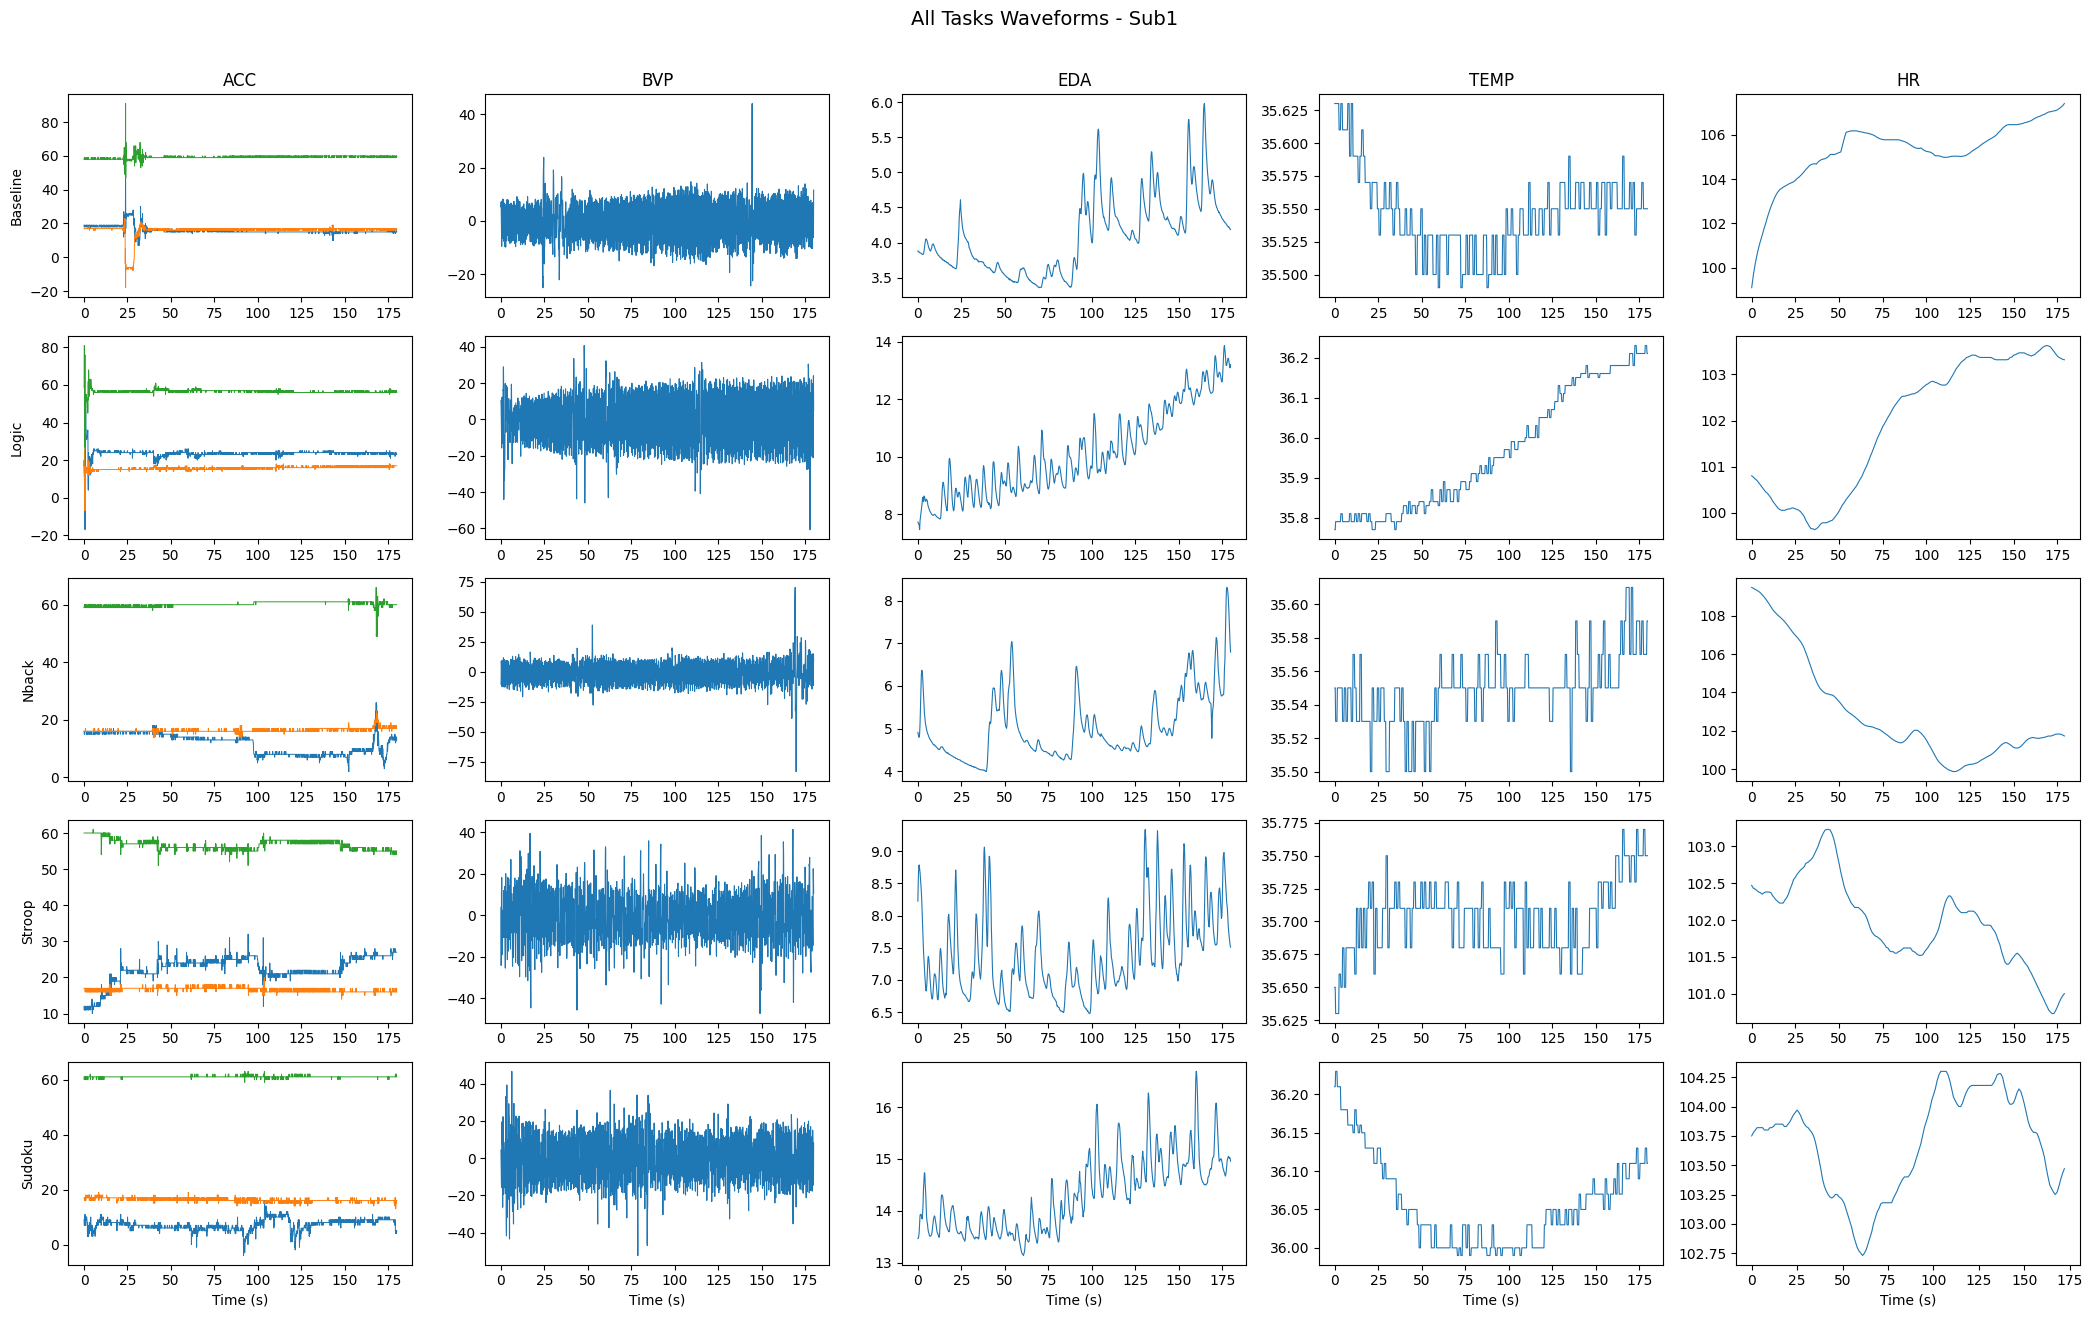

In [3]:
# Plot all tasks for one subject in a task x sensor grid
# You can change this manually, e.g., selected_subject = 'Sub33'
selected_subject = meta['subject'].value_counts().index[0]

task_order = [t for t in ['Baseline', 'Logic', 'Nback', 'Stroop', 'Sudoku'] if t in set(meta['task'])]
sensor_order = [s for s in ['ACC', 'BVP', 'EDA', 'TEMP', 'HR'] if s in set(meta['sensor'])]

subject_df = meta[meta['subject'] == selected_subject].copy()

fig, axes = plt.subplots(
    len(task_order),
    len(sensor_order),
    figsize=(4.2 * len(sensor_order), 2.6 * len(task_order)),
    sharex=False,
)

if len(task_order) == 1 and len(sensor_order) == 1:
    axes = np.array([[axes]])
elif len(task_order) == 1:
    axes = np.array([axes])
elif len(sensor_order) == 1:
    axes = np.array([[ax] for ax in axes])

for i, task in enumerate(task_order):
    for j, sensor in enumerate(sensor_order):
        ax = axes[i, j]

        row = subject_df[(subject_df['task'] == task) & (subject_df['sensor'] == sensor)]
        if row.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
            continue

        p = Path(row.iloc[0]['path'])
        df = pd.read_csv(p)
        fs = FS.get(sensor, 1)

        # Downsample for readability/performance
        stride = max(1, len(df) // 1500)
        t = np.arange(len(df))[::stride] / fs

        if sensor == 'ACC':
            cols = list(df.columns)[:3]
            for c in cols:
                ax.plot(t, df[c].values[::stride], linewidth=0.7)
        else:
            col = df.columns[0]
            ax.plot(t, df[col].values[::stride], linewidth=0.8)

        if i == 0:
            ax.set_title(sensor)
        if j == 0:
            ax.set_ylabel(task)
        if i == len(task_order) - 1:
            ax.set_xlabel('Time (s)')

fig.suptitle(f'All Tasks Waveforms - {selected_subject}', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

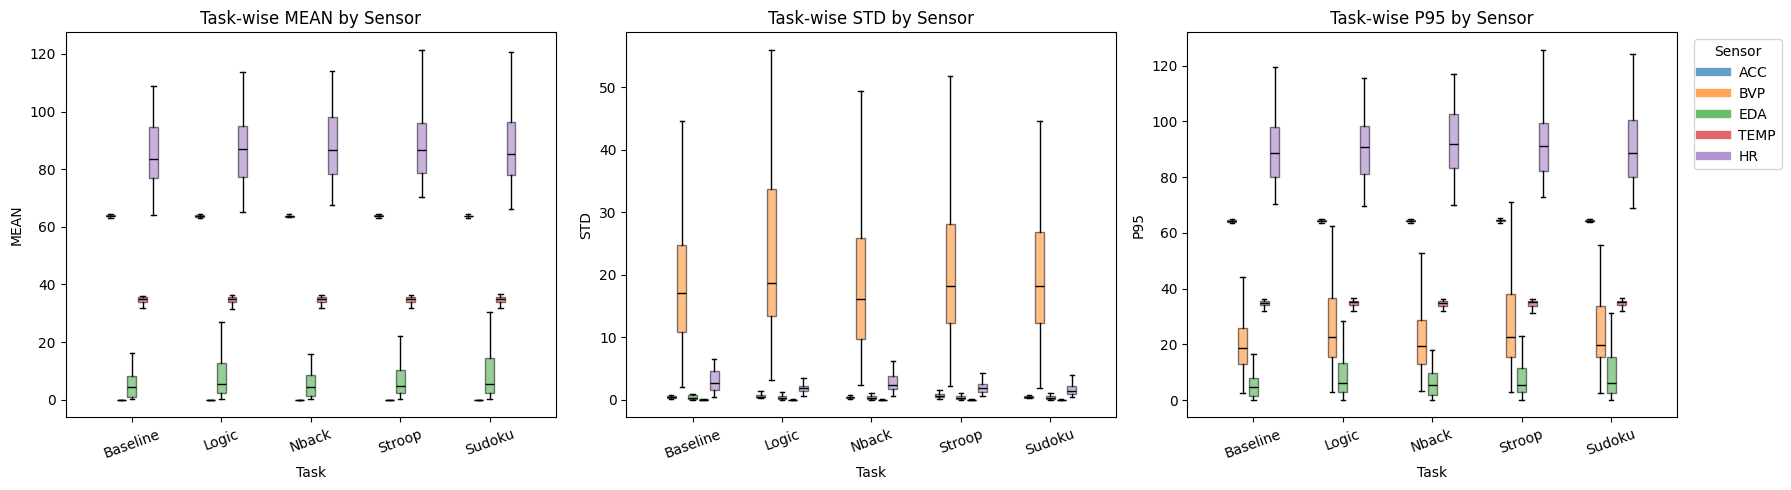

,subject,task,sensor,mean,std,p95
0,Sub1,Baseline,ACC,63.524099,1.056062,64.140471
1,Sub1,Baseline,BVP,0.012754,7.204758,10.350000
2,Sub1,Baseline,EDA,4.094437,0.534231,5.015754
3,Sub1,Baseline,HR,105.247444,1.433136,107.020500
4,Sub1,Baseline,TEMP,35.546333,0.030091,35.610000


In [4]:
# Task-wise global statistics across all subjects
# This gives a clearer comparison than raw waveform-only plots.
stats_rows = []
for _, row in meta.iterrows():
    sensor = row['sensor']
    path = Path(row['path'])
    task = row['task']
    subject = row['subject']

    try:
        df = pd.read_csv(path)
    except Exception:
        continue

    if sensor == 'ACC':
        vals = df.iloc[:, :3].values.astype(float)
        signal = np.linalg.norm(vals, axis=1)
    else:
        signal = df.iloc[:, 0].values.astype(float)

    stats_rows.append(
        {
            'subject': subject,
            'task': task,
            'sensor': sensor,
            'mean': float(np.mean(signal)),
            'std': float(np.std(signal)),
            'p95': float(np.percentile(signal, 95)),
        }
    )

stats_df = pd.DataFrame(stats_rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=False)
metrics = ['mean', 'std', 'p95']

for ax, metric in zip(axes, metrics):
    for sensor in sensor_order:
        plot_df = stats_df[stats_df['sensor'] == sensor]
        data = [plot_df[plot_df['task'] == t][metric].dropna().values for t in task_order]

        # Slight position offset per sensor for side-by-side boxplots
        base = np.arange(len(task_order)) + 1
        offset = (sensor_order.index(sensor) - (len(sensor_order) - 1) / 2) * 0.12
        positions = base + offset

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=0.1,
            patch_artist=True,
            showfliers=False,
        )

        color = plt.cm.tab10(sensor_order.index(sensor) % 10)
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.5)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.0)

    ax.set_title(f'Task-wise {metric.upper()} by Sensor')
    ax.set_xticks(np.arange(len(task_order)) + 1)
    ax.set_xticklabels(task_order, rotation=20)
    ax.set_xlabel('Task')
    ax.set_ylabel(metric.upper())

legend_handles = [
    plt.Line2D([0], [0], color=plt.cm.tab10(i % 10), lw=6, alpha=0.7, label=s)
    for i, s in enumerate(sensor_order)
]
axes[2].legend(handles=legend_handles, title='Sensor', loc='upper left', bbox_to_anchor=(1.02, 1.0))

plt.tight_layout()
plt.show()

stats_df.head()